In [2]:
#pip install torchvision

In [1]:
import torch
import os
from torch.utils.data import DataLoader,Dataset
from torchvision import  transforms
from PIL import Image # python image library

In [10]:
# images load => transform
class ImageProcessor:
    def __init__(self,root_path,transformatioms=None):
        self.c=root_path
        self.transformations=transformations
        # list ofn path for all images 
        self.all_img_paths=[os.path.join(root_dir_path,img) for img in os.listdir(root_dir_path)]
    def __len__(self):
        return len(self.all_img_paths)
    def __getitem__(self,idx):
        img_path=self.all_img_paths[idx]
        img=Image.open(img_path).convert("RGB")
        if self.transformations:
            img=self.transformations(img)
        return img

In [11]:
root_dir_path=r"C:\Users\rjain.RONAKJAIN\Downloads\img_align_celeba\img_align_celeba"
transformations=transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.354,0.5))
])

In [12]:
dataset=ImageProcessor(root_dir_path,transformations)
print(f"loaded{len(dataset)} images")

loaded1775 images


In [14]:
dataloader=DataLoader(dataset,batch_size=128,shuffle=True)

## Generator network

In [24]:
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [31]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, 64 * 64 * img_channels),
            nn.Tanh()
        )

        self.img_channels = img_channels

    def forward(self, z):
        img = self.model(z)

        # Reshape to (batch_size, channels, height, width)
        img = img.view(z.size(0), self.img_channels, 64, 64)

        return img

In [32]:
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self, img_channels=3):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),

            nn.Linear(img_channels * 64 * 64, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)

In [34]:
gan_loss=nn.BCELoss()
generator=Generator()
g_optimizer=optim.Adam(generator.parameters(),lr=0.0002,betas=(0.5,0.999))
discriminator=Discriminator()
d_optimizer=optim.Adam(discriminator.parameters(),lr=0.0002,betas=(0.5,0.999))

In [35]:
import torch
# device 
if torch .backends.mps.is_available():
    device=torch.device("mps")

elif torch.cuda.is_available():
    device=torch.device("cuda")
else:
    device=torch.device("cpu")
print(f"device is {device}")

device is cpu


In [36]:
generator=generator.to(device)
discriminator=discriminator.to(device)

# Training  the GAN 

In [61]:
def train(generator, discriminator, dataloader, epochs=20):

    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size = real_imgs.size(0)

            # creates real imgs labels & fake imgs labels
            real_labels = torch.ones(batch_size, 1).to(device) # [1, 1, 1....]
            fake_labels = torch.zeros(batch_size, 1).to(device) # [0, 0, 0....]

            # Train the Discriminator
            d_optimizer.zero_grad()

            fake_imgs = generator(torch.randn(batch_size, 100).to(device))

            real_loss = gan_loss(discriminator(real_imgs), real_labels)
            fake_loss = gan_loss(discriminator(fake_imgs.detach()), fake_labels)

            d_loss = (real_loss + fake_loss) / 2

            d_loss.backward()
            d_optimizer.step()

            # Train the Generator
            g_optimizer.zero_grad()

            g_loss = gan_loss(discriminator(fake_imgs), real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i % 50 == 0:
                print(f"for epoch: {epoch+1}/{epochs}... batch: {i+1}... G-loss:{g_loss}.... D-loss: {d_loss}")

        # save generated imgs for each epoch
        save_generated_images(generator, epoch, device) 

In [62]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_images(generator, epoch, device, num_imgs=8):
    z = torch.randn(num_imgs, 100).to(device)
    generated_imgs = generator(z).detach().cpu()

    grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)

    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

for epoch: 1/10... batch: 1... G-loss:1.1888689994812012.... D-loss: 0.2685120105743408


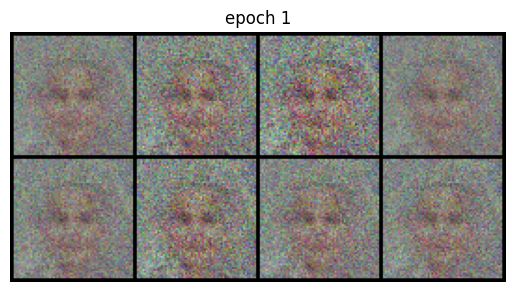

for epoch: 2/10... batch: 1... G-loss:1.461383581161499.... D-loss: 0.20792295038700104


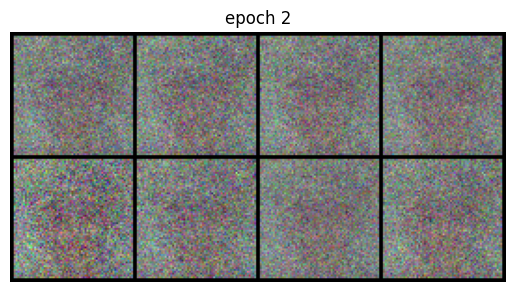

for epoch: 3/10... batch: 1... G-loss:1.7141541242599487.... D-loss: 0.13109765946865082


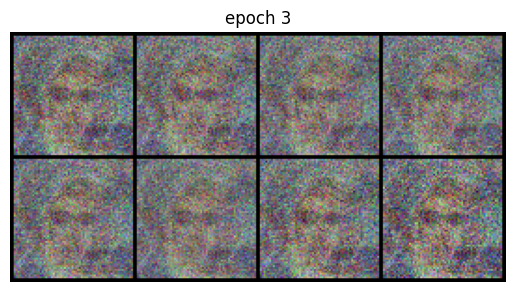

for epoch: 4/10... batch: 1... G-loss:1.9616025686264038.... D-loss: 0.12725988030433655


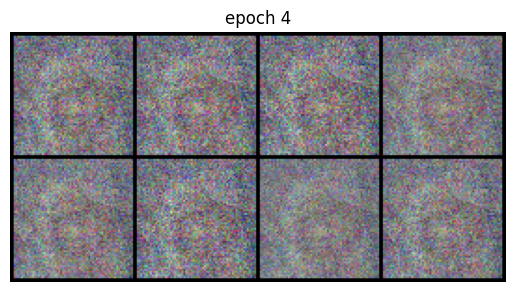

for epoch: 5/10... batch: 1... G-loss:2.6533563137054443.... D-loss: 0.11113457381725311


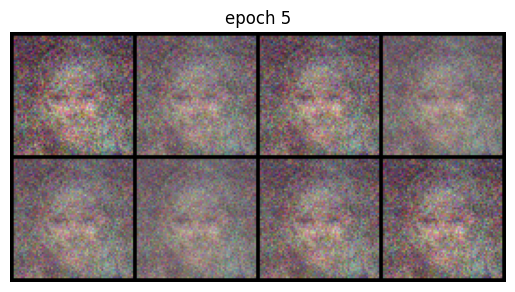

for epoch: 6/10... batch: 1... G-loss:0.8451611995697021.... D-loss: 0.9252162575721741


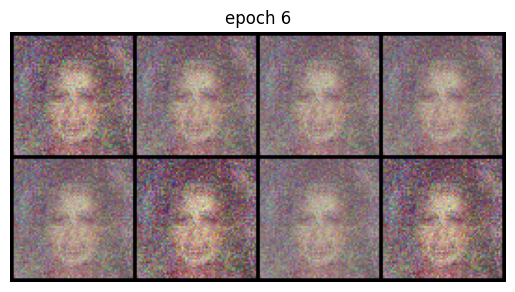

for epoch: 7/10... batch: 1... G-loss:0.7897859215736389.... D-loss: 0.5186222195625305


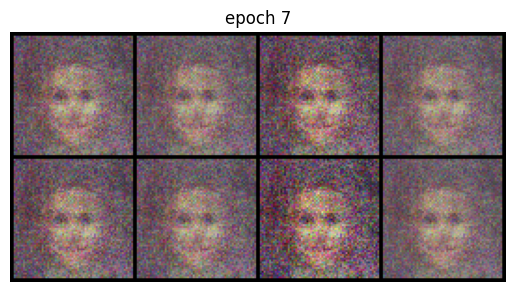

for epoch: 8/10... batch: 1... G-loss:0.7599164247512817.... D-loss: 0.4091629385948181


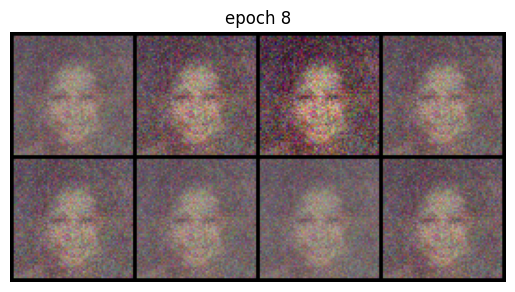

for epoch: 9/10... batch: 1... G-loss:0.6430751085281372.... D-loss: 0.5401910543441772


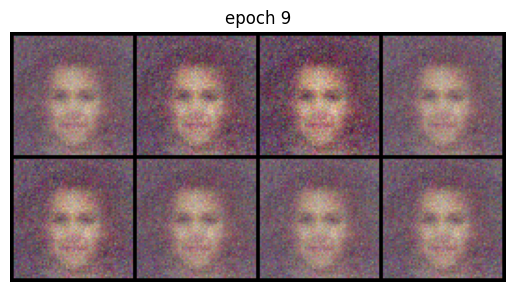

for epoch: 10/10... batch: 1... G-loss:1.2828391790390015.... D-loss: 0.29712343215942383


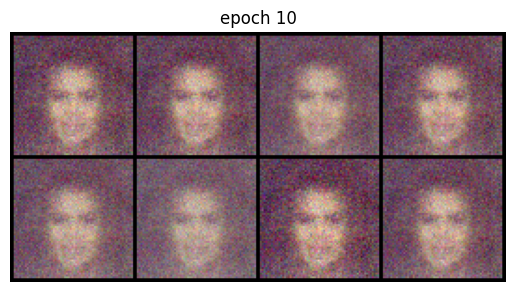

In [63]:
train(generator,discriminator,dataloader,epochs=10)